# MLTP Experiment 4

# Mushroom Classification

#### Subject:Machine Learning Theory and Practice

#### Objective:Predict whether a mushroom is edible or poisonous using Decision Tree Classifier

# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Task1: Exploratory Data Analysis(EDA)

In [3]:
# Load the dataset
columns = [
    'class','cap-shape','cap-surface','cap-color','bruises','odor',
    'gill-attachment','gill-spacing','gill-size','gill-color',
    'stalk-shape','stalk-root','stalk-surface-above-ring',
    'stalk-surface-below-ring','stalk-color-above-ring',
    'stalk-color-below-ring','veil-type','veil-color','ring-number',
    'ring-type','spore-print-color','population','habitat'
]
df=pd.read_csv('C:\\Users\\Brithi S\\Downloads\\mushroom\\agaricus-lepiota.data', header=None, names=columns)
# Display basic information about the dataset
print("\nDataset Shape:", df.shape)
print("\nFirst 5 Rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nSummary Statistics:\n", df.describe())


Dataset Shape: (8124, 23)

First 5 Rows:
   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w             

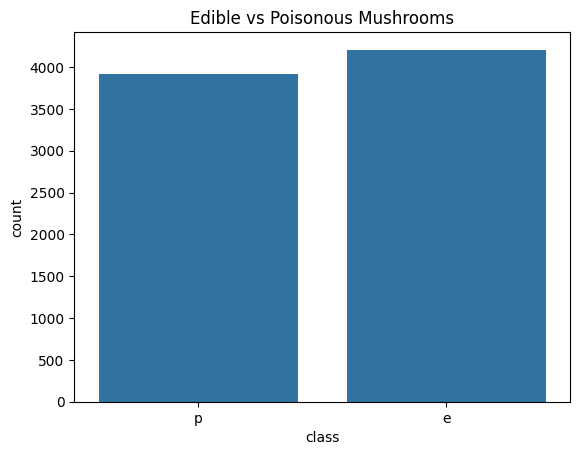

In [4]:
# Visualization
sns.countplot(x='class', data=df)
plt.title('Edible vs Poisonous Mushrooms')
plt.show()

# Task2:Data Cleaning & Transformation

In [5]:
# check for missing values
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [6]:
# Replace '?' with NaN 
import numpy as np
df.replace('?', np.nan, inplace=True)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [7]:
# Fill missing values with mode
for column in df.columns:
    df[column].fillna(df[column].mode()[0], inplace=True)

C:\Users\Brithi S\AppData\Local\Temp\ipykernel_20328\3433165436.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[column].fillna(df[column].mode()[0], inplace=True)


In [8]:
# Label Encoding (convert categorical to numerical)
le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

# Task3:Decision Tree Model Building

In [9]:
# Split features and target
X = df.drop('class', axis=1)
y = df['class']

In [10]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Train Decision Tree 
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Task4: Model Evaluation

In [12]:
# Predictions
y_pred = model.predict(X_test)

In [13]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


Accuracy: 1.0


In [14]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)


Confusion Matrix:
 [[843   0]
 [  0 782]]


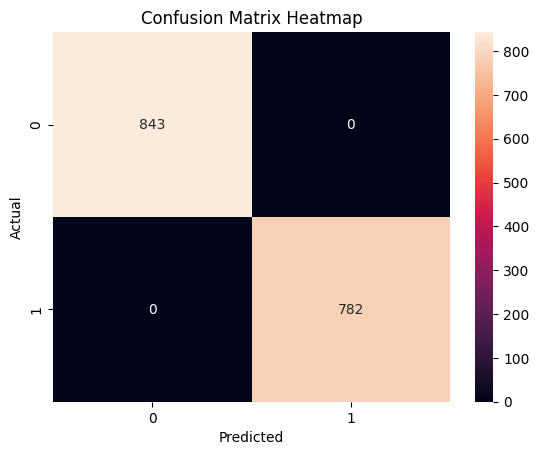

In [16]:
# Heatmap
sns.heatmap(cm, annot=True, fmt='d',)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

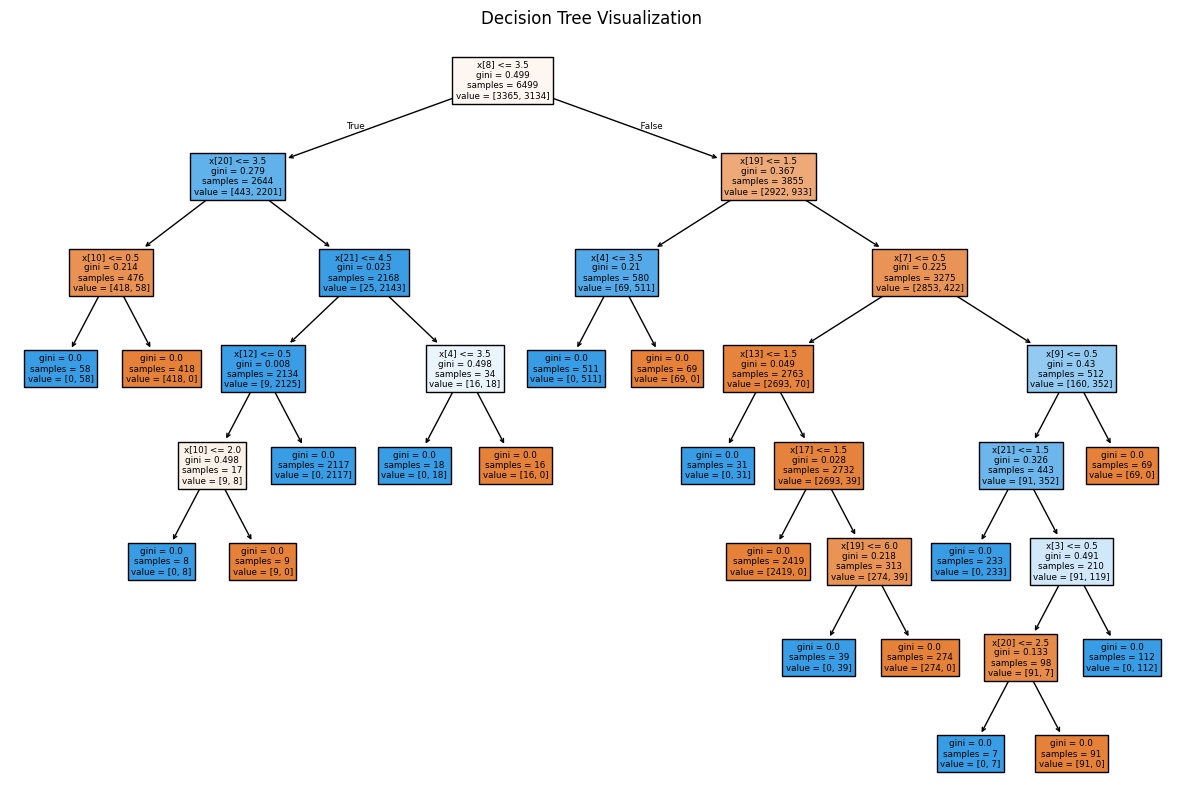

In [17]:
# Visualize Decision Tree
plt.figure(figsize=(15,10))
plot_tree(model, filled=True,)
plt.title('Decision Tree Visualization')
plt.show()

# Task5:Hyperparameter Tuning using Pre-Pruning

In [18]:
results = []

for depth in [3, 5, 10]:
    for split in [2, 5, 10]:
        for leaf in [1, 2, 4]:
            dt = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=split,
                min_samples_leaf=leaf,
                random_state=42
            )
            dt.fit(X_train, y_train)
            pred = dt.predict(X_test)
            acc = accuracy_score(y_test, pred)

            results.append([depth, split, leaf, acc])

In [19]:
# Convert to DataFrame
results_df = pd.DataFrame(results, columns=['Max Depth', 'Min Samples Split', 'Min Samples Leaf', 'Accuracy'])
print("\nHyperparameter Tuning Results:\n", results_df)


Hyperparameter Tuning Results:
     Max Depth  Min Samples Split  Min Samples Leaf  Accuracy
0           3                  2                 1  0.950154
1           3                  2                 2  0.950154
2           3                  2                 4  0.950154
3           3                  5                 1  0.950154
4           3                  5                 2  0.950154
5           3                  5                 4  0.950154
6           3                 10                 1  0.950154
7           3                 10                 2  0.950154
8           3                 10                 4  0.950154
9           5                  2                 1  0.976615
10          5                  2                 2  0.976615
11          5                  2                 4  0.976615
12          5                  5                 1  0.976615
13          5                  5                 2  0.976615
14          5                  5                 4  

In [20]:
# Best Parameters
best=results_df.loc[results_df['Accuracy'].idxmax()]
print("\nBest Hyperparameters:\n",)
print(best)


Best Hyperparameters:

Max Depth            10.0
Min Samples Split     2.0
Min Samples Leaf      1.0
Accuracy              1.0
Name: 18, dtype: float64
